In [1]:
import numpy as np
import pyvista as pv
from skimage import measure

# --- 1. The Math: SDF & Projection ---

def smin(a, b, k):
    """Polynomial Smooth Minimum (The 'Blob' function)."""
    h = np.maximum(k - np.abs(a - b), 0.0) / k
    return np.minimum(a, b) - h * h * h * k * (1.0 / 6.0)

def sdf_sphere(p, center, radius):
    return np.linalg.norm(p - center, axis=1) - radius

class BlobModel:
    def __init__(self):
        self.res = 50  # Grid resolution (higher = smoother but slower)
        limit = 3.0
        x = np.linspace(-limit, limit, self.res)
        y = np.linspace(-limit, limit, self.res)
        z = np.linspace(-limit, limit, self.res)
        self.X, self.Y, self.Z = np.meshgrid(x, y, z, indexing='ij')
        self.grid_points = np.stack([self.X.ravel(), self.Y.ravel(), self.Z.ravel()], axis=1)

        # Fake "Original Mesh" vertices to demonstrate projection
        # We put them slightly outside where the blob will be
        theta = np.linspace(0, 2*np.pi, 20)
        self.targets = np.column_stack([
            2.2 * np.cos(theta),
            np.zeros_like(theta),
            2.2 * np.sin(theta)
        ])

    def evaluate(self, sep, scale, smooth):
        """
        Calculates the Signed Distance Field for the hierarchy.
        Returns: Distance field array
        """
        # Level 0: Root Sphere (Center)
        d_root = sdf_sphere(self.grid_points, np.array([0,0,0]), 1.0)

        # Level 1: Two Children (Left and Right)
        # Note: In a real compressor, these positions would be optimized.
        c1_pos = np.array([sep, 0, 0])
        c2_pos = np.array([-sep, 0, 0])
        child_rad = 1.0 * scale

        d_c1 = sdf_sphere(self.grid_points, c1_pos, child_rad)
        d_c2 = sdf_sphere(self.grid_points, c2_pos, child_rad)

        # Smooth Union of Children
        d_children = smin(d_c1, d_c2, smooth)

        # Smooth Union with Root
        d_final = smin(d_root, d_children, smooth)

        return d_final

    def get_mesh(self, sep, scale, smooth):
        """Generates a PyVista mesh from the SDF."""
        vol = self.evaluate(sep, scale, smooth).reshape((self.res, self.res, self.res))

        try:
            # Marching Cubes to get vertices/faces
            verts, faces, normals, values = measure.marching_cubes(vol, level=0.0)

            # Map grid coordinates back to world coordinates
            verts = verts * (6.0 / (self.res - 1)) - 3.0

            # Create PyVista PolyData
            # PyVista requires faces to have a size indicator (3 for triangles)
            faces_pv = np.column_stack((np.full(len(faces), 3), faces)).flatten()
            mesh = pv.PolyData(verts, faces_pv)
            return mesh
        except:
            return None

    def get_projections(self, mesh, sep, scale, smooth):
        """
        Demonstrates the 'Compression Residuals'.
        Finds the closest point on the blob for our target vertices.
        """
        if mesh is None or mesh.n_points == 0:
            return None

        # PyVista has a fast KD-Tree locator
        closest_points = []
        for target in self.targets:
            # Find closest point on the generated blob surface
            idx = mesh.find_closest_point(target)
            closest_points.append(mesh.points[idx])

        return np.array(closest_points)

# --- 2. Visualization Setup ---

model = BlobModel()
plotter = pv.Plotter()

# Initial State
init_sep = 1.2
init_scale = 0.7
init_smooth = 0.5

# Placeholders for actors (the 3D objects)
mesh_actor = None
lines_actor = None
points_actor = None
# --- 3. UI Controls & Callback ---

# placeholders for the widgets so we can reference them safely
s_sep_widget = None
s_scale_widget = None
s_smooth_widget = None

def callback(value=None):
    """Called whenever a slider moves."""
    global mesh_actor, lines_actor, points_actor

    # SAFETY CHECK: If the sliders aren't all created yet, do nothing.
    if len(plotter.slider_widgets) < 3:
        return

    # Get values safely from the list
    sep = plotter.slider_widgets[0].GetRepresentation().GetValue()
    scale = plotter.slider_widgets[1].GetRepresentation().GetValue()
    smooth = plotter.slider_widgets[2].GetRepresentation().GetValue()

    # 1. Generate the Blob Mesh
    mesh = model.get_mesh(sep, scale, smooth)
    if mesh is None: return

    # 2. Calculate "Residuals" (Projections)
    # Note: In a real app, you would optimize 'sep', 'scale', 'smooth'
    # automatically to minimize the length of these lines.
    projected_points = model.get_projections(mesh, sep, scale, smooth)

    # --- Update the Scene ---

    # Remove old actors if they exist
    if mesh_actor: plotter.remove_actor(mesh_actor)
    if lines_actor: plotter.remove_actor(lines_actor)
    if points_actor: plotter.remove_actor(points_actor)

    # Add new Blob
    mesh_actor = plotter.add_mesh(mesh, color="lightblue", smooth_shading=True, specular=0.5)

    # Add Target Points (Red dots)
    points_actor = plotter.add_points(model.targets, color="red", point_size=10, render_points_as_spheres=True)

    # Add Projection Lines (White lines)
    if projected_points is not None and len(projected_points) > 0:
        lines = []
        all_pts = []
        curr_idx = 0

        # Build lines for PyVista (format: [2, pt_a, pt_b, 2, pt_c, pt_d...])
        for i, target in enumerate(model.targets):
            all_pts.append(target)
            all_pts.append(projected_points[i])
            lines.append([2, curr_idx, curr_idx+1])
            curr_idx += 2

        lines_poly = pv.PolyData(np.array(all_pts))
        lines_poly.lines = np.hstack(lines)
        lines_actor = plotter.add_mesh(lines_poly, color="white", line_width=2)

# Create the sliders
plotter.add_slider_widget(callback, [0.0, 2.5], value=init_sep, title="Child Offset", pointa=(0.025, 0.9), pointb=(0.25, 0.9))
plotter.add_slider_widget(callback, [0.1, 1.2], value=init_scale, title="Child Scale", pointa=(0.025, 0.75), pointb=(0.25, 0.75))
plotter.add_slider_widget(callback, [0.1, 1.5], value=init_smooth, title="Smoothness", pointa=(0.025, 0.6), pointb=(0.25, 0.6))

# NOW it is safe to manually trigger the first draw
callback()

plotter.show()

Widget(value='<iframe src="http://localhost:59773/index.html?ui=P_0x1ddc64a8550_0&reconnect=auto" class="pyvis…

Using device: cuda
Starting Optimization...
Epoch 0: Loss = 0.467680
Epoch 50: Loss = 0.068461
Epoch 100: Loss = 0.052261
Epoch 150: Loss = 0.029327
Epoch 200: Loss = 0.023901
Epoch 250: Loss = 0.021600
Epoch 300: Loss = 0.018039
Epoch 350: Loss = 0.014484
Epoch 400: Loss = 0.012330
Epoch 450: Loss = 0.011295
Optimization Complete.

--- Results ---
Mean Residual Error: 0.06140
Max Residual Error:  0.47163
Note: In a compression pipeline, these small residuals are what you store.


Widget(value='<iframe src="http://localhost:59773/index.html?ui=P_0x1dde3f3ea50_1&reconnect=auto" class="pyvis…

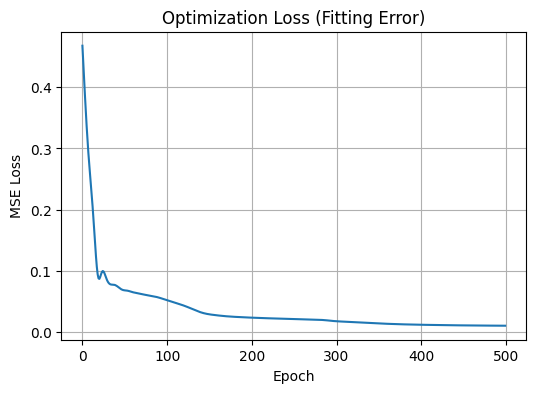

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Differentiable SDF Logic (PyTorch) ---

def smin_torch(a, b, k):
    """Differentiable Smooth Minimum (Polynomial)."""
    h = torch.max(k - torch.abs(a - b), torch.zeros_like(a)) / k
    return torch.min(a, b) - h * h * h * k * (1.0 / 6.0)

class HierarchicalBlobTree(nn.Module):
    def __init__(self, depth=3):
        super().__init__()
        self.depth = depth

        # --- Learnable Parameters ---
        # We store RELATIVE transformations (offsets) and Scaling factors.
        # This mimics the compression structure: we only need to store these deltas.

        # Level 1 (2 children)
        self.l1_offset = nn.Parameter(torch.randn(2, 3) * 0.5) # Random start
        self.l1_scale  = nn.Parameter(torch.ones(2) * 0.7)

        # Level 2 (4 children, 2 per parent)
        self.l2_offset = nn.Parameter(torch.randn(4, 3) * 0.3)
        self.l2_scale  = nn.Parameter(torch.ones(4) * 0.7)

        # Level 3 (8 children, 2 per parent)
        self.l3_offset = nn.Parameter(torch.randn(8, 3) * 0.2)
        self.l3_scale  = nn.Parameter(torch.ones(8) * 0.7)

        # Global Smoothness (Learnable)
        self.smoothness = nn.Parameter(torch.tensor(0.5))

    def get_spheres(self):
        """
        Computes the absolute world position and radius for every sphere
        by traversing the hierarchy.
        """
        # Root (Fixed)
        root_pos = torch.zeros(1, 3, device=device)
        root_rad = torch.ones(1, device=device)

        # Level 1 Absolute
        # Positions = Root + L1_Offset
        l1_pos = root_pos + self.l1_offset
        l1_rad = root_rad * self.l1_scale

        # Level 2 Absolute
        # We repeat L1 parents to match L2 children (0->0,1; 1->2,3)
        l1_expanded = l1_pos.repeat_interleave(2, dim=0)
        l1_rad_expanded = l1_rad.repeat_interleave(2, dim=0)

        l2_pos = l1_expanded + self.l2_offset
        l2_rad = l1_rad_expanded * self.l2_scale

        # Level 3 Absolute
        l2_expanded = l2_pos.repeat_interleave(2, dim=0)
        l2_rad_expanded = l2_rad.repeat_interleave(2, dim=0)

        l3_pos = l2_expanded + self.l3_offset
        l3_rad = l2_rad_expanded * self.l3_scale

        # Collect all active primitives
        # (We use all levels for the final shape, or just leaves. Let's use all for smoothness)
        all_pos = torch.cat([root_pos, l1_pos, l2_pos, l3_pos], dim=0)
        all_rad = torch.cat([root_rad, l1_rad, l2_rad, l3_rad], dim=0)

        return all_pos, all_rad

    def forward(self, x):
        """
        Calculates SDF(x) for the whole tree.
        x: (Batch, 3) points
        """
        centers, radii = self.get_spheres()
        k = torch.clamp(self.smoothness, 0.01, 2.0)

        # Vectorized distance calculation
        # x: (N, 1, 3) vs centers: (1, M, 3) -> dists: (N, M)
        x_expanded = x.unsqueeze(1)
        c_expanded = centers.unsqueeze(0)

        dists = torch.norm(x_expanded - c_expanded, dim=2) - radii

        # Soft Union of all spheres
        # We iteratively blend them into a single field value per point
        # Start with the first sphere's distance
        d_final = dists[:, 0]

        for i in range(1, dists.shape[1]):
            d_final = smin_torch(d_final, dists[:, i], k)

        return d_final

# --- 2. Generate Target Data (A "Bent Tube") ---

def create_target_shape(num_points=2000):
    """Creates a point cloud of a bent cylinder (Boomerang shape)."""
    t = np.linspace(-np.pi/2, np.pi/2, num_points)

    # Main curve (Arch)
    curve_x = 2.0 * np.sin(t)
    curve_y = 2.0 * np.cos(t) - 1.0 # Offset y
    curve_z = np.zeros_like(t)

    # Add volume (tube thickness)
    # Random normal vectors
    normals = np.random.randn(num_points, 3)
    normals = normals / np.linalg.norm(normals, axis=1, keepdims=True)

    thickness = 0.5
    points = np.stack([curve_x, curve_y, curve_z], axis=1) + normals * thickness

    return torch.tensor(points, dtype=torch.float32).to(device)

target_points = create_target_shape()

# --- 3. Optimization Loop (Corrected) ---

model = HierarchicalBlobTree(depth=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.02)

print("Starting Optimization...")
losses = []

for epoch in range(500):
    optimizer.zero_grad()

    # Forward Pass: Get distance from target points to our surface
    sdf_values = model(target_points)

    # Loss 1: Surface Fitting (MSE)
    fit_loss = torch.mean(sdf_values**2)

    # Loss 2: Regularization (Prevent infinite scaling)
    # FIX: Calculate mean separately for tensors of different shapes
    reg_loss = 0.01 * (
        torch.mean(model.l1_scale**2) +
        torch.mean(model.l2_scale**2) +
        torch.mean(model.l3_scale**2)
    )

    loss = fit_loss + reg_loss

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

print("Optimization Complete.")

# --- 4. Visualization & Metrics ---

# A. Evaluate Final Grid for Mesh Generation
model.eval()
with torch.no_grad():
    res = 60
    grid_dim = 4.0
    x = np.linspace(-grid_dim, grid_dim, res)
    y = np.linspace(-grid_dim, grid_dim, res)
    z = np.linspace(-grid_dim, grid_dim, res)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    grid_pts = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    grid_tensor = torch.tensor(grid_pts, dtype=torch.float32).to(device)

    # Chunking to avoid OOM on GPU
    vol_chunks = []
    chunk_size = 10000
    for i in range(0, len(grid_tensor), chunk_size):
        vol_chunks.append(model(grid_tensor[i:i+chunk_size]).cpu().numpy())

    vol = np.concatenate(vol_chunks).reshape(res, res, res)

    # Calculate Final Residuals for Histogram
    final_residuals = model(target_points).cpu().numpy()

# B. PyVista Visualization
pv.set_plot_theme("document")
pl = pv.Plotter(shape=(1, 2))

# Subplot 1: The 3D Result
pl.subplot(0, 0)
pl.add_text("Optimized Implicit Surface (Blue) vs Target (Red)", font_size=10)

# 1. Target Points
pl.add_points(target_points.cpu().numpy(), color="red", point_size=4, render_points_as_spheres=True, opacity=0.5)

# 2. Optimized Mesh (Isosurface at 0)
try:
    from skimage import measure
    verts, faces, _, _ = measure.marching_cubes(vol, level=0.0)
    verts = verts * (2*grid_dim / (res - 1)) - grid_dim # Scale back to world

    # Fix faces for PyVista
    faces_pv = np.column_stack((np.full(len(faces), 3), faces)).flatten()
    mesh = pv.PolyData(verts, faces_pv)

    pl.add_mesh(mesh, color="lightblue", opacity=0.6, smooth_shading=True, show_edges=False)

    # 3. Visualize the "Skeleton" (Sphere Centers)
    with torch.no_grad():
        ctrs, rads = model.get_spheres()
        ctrs = ctrs.cpu().numpy()
        rads = rads.cpu().numpy()
        for i in range(len(ctrs)):
            # Draw wireframe spheres for the hierarchy structure
            sphere = pv.Sphere(radius=float(rads[i]), center=ctrs[i])
            pl.add_mesh(sphere, style='wireframe', color='black', opacity=0.2)

except Exception as e:
    print(f"Meshing failed (shape might be empty): {e}")


# Subplot 2: Residuals Analysis
pl.subplot(0, 1)
pl.add_text("Residual Distribution (Compression Potential)", font_size=10)

# Create a 2D Chart within PyVista (using matplotlib backend image usually, but here simple text/chart)
# Since PyVista charts are limited, we'll print stats and show a colored scalar bar on the points
pl.add_points(target_points.cpu().numpy(), scalars=final_residuals, cmap="coolwarm", point_size=5, render_points_as_spheres=True)
pl.add_scalar_bar(title="Residual Distance (Target - Surface)")

print(f"\n--- Results ---")
print(f"Mean Residual Error: {np.mean(np.abs(final_residuals)):.5f}")
print(f"Max Residual Error:  {np.max(np.abs(final_residuals)):.5f}")
print("Note: In a compression pipeline, these small residuals are what you store.")

pl.link_views()
pl.show()

# Optional: Show Loss Curve using Matplotlib
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Optimization Loss (Fitting Error)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Math Helpers (SDF & Geometry) ---

def smin_torch(a, b, k):
    """Differentiable Smooth Minimum."""
    h = torch.max(k - torch.abs(a - b), torch.zeros_like(a)) / k
    return torch.min(a, b) - h * h * h * k * (1.0 / 6.0)

def cartesian_to_spherical(xyz):
    """
    Converts (N, 3) XYZ to (N, 3) Spherical (r, theta, phi).
    theta = polar angle (0..pi), phi = azimuth (-pi..pi)
    """
    r = torch.norm(xyz, dim=1)
    # Clamp for safety
    theta = torch.acos(torch.clamp(xyz[:, 1] / (r + 1e-6), -1.0, 1.0)) # y is up
    phi = torch.atan2(xyz[:, 2], xyz[:, 0])
    return torch.stack([r, theta, phi], dim=1)

# --- 2. The Parametric Model ---

class HierarchicalBlobTree(nn.Module):
    def __init__(self, depth=2):
        super().__init__()
        self.depth = depth

        # Learnable Parameters (Offsets & Scales)
        # Using a slightly constrained setup to ensure it stays "sphere-like"
        self.l1_offset = nn.Parameter(torch.randn(2, 3) * 0.5)
        self.l1_scale  = nn.Parameter(torch.ones(2) * 0.6)

        if depth >= 2:
            self.l2_offset = nn.Parameter(torch.randn(4, 3) * 0.3)
            self.l2_scale  = nn.Parameter(torch.ones(4) * 0.6)

        self.smoothness = nn.Parameter(torch.tensor(0.5))

    def get_spheres(self):
        root_pos = torch.zeros(1, 3, device=device)
        root_rad = torch.ones(1, device=device)

        # Level 1
        l1_pos = root_pos + self.l1_offset
        l1_rad = root_rad * self.l1_scale

        all_pos = [root_pos, l1_pos]
        all_rad = [root_rad, l1_rad]

        # Level 2
        if self.depth >= 2:
            l1_expanded = l1_pos.repeat_interleave(2, dim=0)
            l1_rad_expanded = l1_rad.repeat_interleave(2, dim=0)
            l2_pos = l1_expanded + self.l2_offset
            l2_rad = l1_rad_expanded * self.l2_scale
            all_pos.append(l2_pos)
            all_rad.append(l2_rad)

        return torch.cat(all_pos, dim=0), torch.cat(all_rad, dim=0)

    def forward(self, x):
        """Calculates Signed Distance (SDF) from x to the blob surface."""
        centers, radii = self.get_spheres()
        k = torch.clamp(self.smoothness, 0.01, 2.0)

        x_expanded = x.unsqueeze(1)
        c_expanded = centers.unsqueeze(0)

        # Distance to each sphere
        dists = torch.norm(x_expanded - c_expanded, dim=2) - radii

        # Smooth Union
        d_final = dists[:, 0]
        for i in range(1, dists.shape[1]):
            d_final = smin_torch(d_final, dists[:, i], k)

        return d_final

    def ray_march_radius(self, directions, max_steps=30):
        """
        Finds the surface radius r along given directions.
        Used for Compression Prediction (NOT for training).
        """
        # Start at origin (r=0)
        # We march outwards. Note: Since we are inside the shape (usually),
        # SDF is negative. We march until SDF hits 0.

        t = torch.zeros(directions.shape[0], device=device)

        # Simple Sphere Tracing (optimized for convex-ish shapes)
        # We assume origin is inside.
        for _ in range(max_steps):
            p = directions * t.unsqueeze(1)
            dist = self.forward(p) # This returns negative if inside

            # If inside, we move forward by |dist|. If outside, we move back.
            # However, standard sphere tracing assumes we are outside.
            # Let's assume we start inside: dist is negative.
            # We want to reach dist = 0.

            # Robust step: move by absolute distance
            t = t + torch.abs(dist) * 0.9 # 0.9 is relaxation to prevent overshooting

        return t

# --- 3. Data Generation (Target) ---

def create_target_shape(num_points=3000):
    """Creates a deformed sphere (e.g., a Peanut/Dumbbell)."""
    # Create random points on a sphere
    vecs = torch.randn(num_points, 3, device=device)
    vecs = vecs / torch.norm(vecs, dim=1, keepdim=True)

    # Deform radius based on angle (Peanut shape logic)
    # x-axis stretch
    stretch = 1.5 * torch.abs(vecs[:, 0]) + 0.5
    points = vecs * stretch.unsqueeze(1)

    return points

target_points = create_target_shape()

# --- 4. Optimization ---

model = HierarchicalBlobTree(depth=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.02)

print("1. Optimizing Parametric Model...")

for epoch in range(2000):
    optimizer.zero_grad()

    # SDF Loss: We want the surface to pass through the points
    # (i.e., SDF at points should be 0)
    dist = model(target_points)
    loss = torch.mean(dist**2) + 0.001 * torch.mean(model.l1_scale**2)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"   Epoch {epoch}: MSE Loss = {loss.item():.6f}")

# --- 5. Compression / Calculation Step ---

print("\n2. Calculating Residuals (Encoding)...")

with torch.no_grad():
    # A. Get Spherical Directions for all vertices
    # Normalize inputs to get direction vectors
    r_actual = torch.norm(target_points, dim=1)
    directions = target_points / r_actual.unsqueeze(1)

    # B. Predict Surface Radius (Ray Marching the Model)
    # "Where does the model think the surface is?"
    r_pred = model.ray_march_radius(directions)

    # C. Calculate Residuals
    # "How much do we need to push the vertex to match reality?"
    residuals = r_actual - r_pred

    # D. Reconstruct (Decoding Check)
    reconstructed_points = directions * (r_pred + residuals).unsqueeze(1)

# --- 6. Metrics & Visualization ---

res_np = residuals.cpu().numpy()
print(f"\n--- Compression Stats ---")
print(f"Original Radius Range: {r_actual.min():.2f} to {r_actual.max():.2f}")
print(f"Residuals Range:       {res_np.min():.4f} to {res_np.max():.4f}")
print(f"Mean Absolute Error:   {np.mean(np.abs(res_np)):.4f}")
print(f"Compression Gain:      Residuals are {(np.std(res_np) / np.std(r_actual.cpu().numpy())) * 100:.1f}% the variance of original data.")

# Visualization
pv.set_plot_theme("document")
pl = pv.Plotter(shape=(1, 2))

# Plot 1: The Model vs Real
pl.subplot(0, 0)
pl.add_text("Left: Fitted Model (Blue) vs Input (Red)", font_size=10)

# Show Input Points
pl.add_points(target_points.cpu().numpy(), color="red", point_size=4, render_points_as_spheres=True, opacity=0.5)

# Show Fitted Isosurface
try:
    # Evaluate grid for isosurface extraction
    grid_dim = 3.0
    res = 50
    x = np.linspace(-grid_dim, grid_dim, res)
    y = np.linspace(-grid_dim, grid_dim, res)
    z = np.linspace(-grid_dim, grid_dim, res)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    grid_pts = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    grid_tensor = torch.tensor(grid_pts, dtype=torch.float32).to(device)

    with torch.no_grad():
        vol = model(grid_tensor).reshape(res, res, res).cpu().numpy()

    from skimage import measure
    verts, faces, _, _ = measure.marching_cubes(vol, level=0.0)
    verts = verts * (2*grid_dim / (res - 1)) - grid_dim
    faces_pv = np.column_stack((np.full(len(faces), 3), faces)).flatten()
    mesh = pv.PolyData(verts, faces_pv)
    pl.add_mesh(mesh, color="lightblue", opacity=0.5, smooth_shading=True)
except:
    pass

# Plot 2: The Residuals Visualization
pl.subplot(0, 1)
pl.add_text("Right: Compression Residuals (Zoom In)", font_size=10)

# We visualize residuals as lines from the Predicted Surface to the Actual Point
# Ideally, these lines should be very short.
start_pts = (directions * r_pred.unsqueeze(1)).cpu().numpy()
end_pts   = target_points.cpu().numpy()

# Draw arrows/lines
lines_actor = pl.add_arrows(start_pts, end_pts - start_pts, mag=1.0, color="orange")
# Color the points by residual magnitude
pl.add_points(end_pts, scalars=res_np, cmap="coolwarm", point_size=5, render_points_as_spheres=True)
pl.add_scalar_bar("Residual Magnitude")

pl.link_views()
pl.show()

Using device: cuda
1. Optimizing Parametric Model...
   Epoch 0: MSE Loss = 0.236762
   Epoch 100: MSE Loss = 0.030119
   Epoch 200: MSE Loss = 0.028797
   Epoch 300: MSE Loss = 0.028492
   Epoch 400: MSE Loss = 0.028403
   Epoch 500: MSE Loss = 0.028332
   Epoch 600: MSE Loss = 0.028275
   Epoch 700: MSE Loss = 0.028229
   Epoch 800: MSE Loss = 0.028193
   Epoch 900: MSE Loss = 0.028163
   Epoch 1000: MSE Loss = 0.028138
   Epoch 1100: MSE Loss = 0.028117
   Epoch 1200: MSE Loss = 0.028100
   Epoch 1300: MSE Loss = 0.028085
   Epoch 1400: MSE Loss = 0.028073
   Epoch 1500: MSE Loss = 0.028062
   Epoch 1600: MSE Loss = 0.028053
   Epoch 1700: MSE Loss = 0.028044
   Epoch 1800: MSE Loss = 0.028037
   Epoch 1900: MSE Loss = 0.028030

2. Calculating Residuals (Encoding)...

--- Compression Stats ---
Original Radius Range: 0.50 to 2.00
Residuals Range:       -0.4996 to 0.0105
Mean Absolute Error:   0.0891
Compression Gain:      Residuals are 33.2% the variance of original data.


Widget(value='<iframe src="http://localhost:59773/index.html?ui=P_0x1ddf1ca7e90_2&reconnect=auto" class="pyvis…

In [4]:
import numpy as np

from reader import *
from encoder import *

bunny_model = Reader.read_from_file('assets/bunny.obj')


In [5]:
import math
def cartesian_to_spherical(x, y, z):
    r = math.sqrt(x**2 + y**2 + z**2)
    theta = math.acos(z / r) if r != 0 else 0.0  # polar angle [0, π]
    phi = math.atan2(y, x)            # [0, 2π]
    return r, theta, phi


In [6]:
spherical_vertices = [cartesian_to_spherical(vertex.x, vertex.y, vertex.z) for vertex in bunny_model.vertices]

In [7]:
spherical_vertices_angles = np.array([vertex[1:] for vertex in spherical_vertices])
spherical_vertices_angles[:, 0] /= np.pi
spherical_vertices_angles[:, 1] /= 2 * np.pi

In [8]:
spherical_vertices_angles

array([[0.44736739, 0.25416379],
       [0.44596484, 0.32829166],
       [0.49727856, 0.28820683],
       ...,
       [0.54114817, 0.263144  ],
       [0.5832527 , 0.31848969],
       [0.43294516, 0.37178488]])

--- Compression Results ---
Original Data:   160192 bits (Global 32-bit coords)
Compressed Data: 38842 bits (Tree Header + Local Quantization)
Ratio:           4.12x
Tree Nodes:      1451 internal nodes
Tree Leaves:     1452 leaf nodes


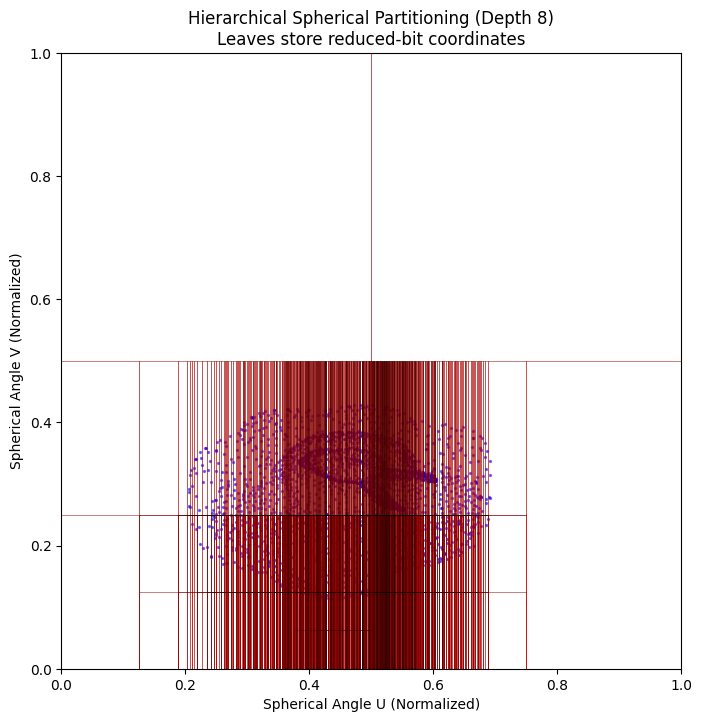

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. Data Prep (Spherical -> UV) ---

def generate_spherical_data(n=100):
    """Generates random clusters of points on a sphere (UV space)."""
    # Create 3 clusters
    c1 = np.random.normal(0.2, 0.05, (n//3, 2))
    c2 = np.random.normal(0.7, 0.05, (n//3, 2))
    c3 = np.random.normal(0.5, 0.15, (n//3, 2))
    data = np.vstack([c1, c2, c3])

    # Clamp to [0, 1] (Normalized Spherical Coordinates)
    # U = theta / pi, V = phi / (2*pi)
    data = np.clip(data, 0.0, 0.9999)
    return data

# --- 2. The Compression Tree ---

class Node:
    def __init__(self, bounds, depth, axis):
        self.bounds = bounds  # (min_u, min_v, max_u, max_v)
        self.depth = depth
        self.axis = axis      # 0 for U (theta), 1 for V (phi)
        self.points = None    # Only leaves hold data
        self.left = None
        self.right = None
        self.count = 0        # Total points in this subtree

def build_tree(points, bounds, depth, max_depth, axis):
    node = Node(bounds, depth, axis)
    node.count = len(points)

    # Stop conditions
    if depth >= max_depth or len(points) <= 5: # Leaf node
        node.points = points
        return node

    # Split bounds
    min_u, min_v, max_u, max_v = bounds
    mid_u = (min_u + max_u) / 2
    mid_v = (min_v + max_v) / 2

    left_mask = None
    left_bounds = None
    right_bounds = None

    # Split Logic (Alternate Axis)
    if axis == 0: # Split U (Vertical line)
        left_mask = points[:, 0] < mid_u
        left_bounds = (min_u, min_v, mid_u, max_v)
        right_bounds = (mid_u, min_v, max_u, max_v)
    else: # Split V (Horizontal line)
        left_mask = points[:, 1] < mid_v
        left_bounds = (min_u, min_v, max_u, mid_v)
        right_bounds = (min_u, min_v, max_u, max_v)

    # Recurse
    # Next axis: (0->1, 1->0)
    next_axis = 1 - axis

    node.left = build_tree(points[left_mask], left_bounds, depth+1, max_depth, next_axis)
    node.right = build_tree(points[~left_mask], right_bounds, depth+1, max_depth, next_axis)

    return node

# --- 3. Simulation of "Bit Savings" ---

def analyze_compression(node, global_precision_bits=16, stats=None):
    if stats is None: stats = {'total_bits': 0, 'header_ints': 0, 'leaves': 0}

    if node.left is None: # Is Leaf
        # --- The "Win" ---
        # Global range is [0,1]. Node range is [min, max].
        # The range size is 1 / (2^(depth/2)).
        # We effectively save 'depth/2' bits per coordinate.

        # Simple heuristic: Each split halves ONE dimension.
        # Total splits = depth.
        # U_splits = depth // 2 + depth % 2
        # V_splits = depth // 2

        u_bits_needed = global_precision_bits - (node.depth + 1) // 2
        v_bits_needed = global_precision_bits - (node.depth) // 2

        # Total bits for this leaf's payload
        # N points * (Reduced U bits + Reduced V bits)
        bits_for_points = len(node.points) * (u_bits_needed + v_bits_needed)
        stats['total_bits'] += bits_for_points
        stats['leaves'] += 1
        return

    # Is Node (Header)
    # We need to store ONE integer: "How many points went Left?"
    # The decoder knows 'Total Points' from the parent, so Right = Total - Left.
    # We define a "Header Integer" as roughly 16 bits (or log2(parent.count))
    header_cost = np.ceil(np.log2(node.count + 1))
    stats['total_bits'] += header_cost
    stats['header_ints'] += 1

    analyze_compression(node.left, global_precision_bits, stats)
    analyze_compression(node.right, global_precision_bits, stats)
    return stats

# --- 4. Execution & Visualization ---

# A. Generate Data
# original_points = generate_spherical_data(2000)
original_points = spherical_vertices_angles.copy()
global_bits = 16 # 65536 grid resolution

# B. Build Tree
# Start with bounds 0..1, 0..1, Depth 0, Axis 0 (U)
root = build_tree(original_points, (0, 0, 1, 1), 0, max_depth=24, axis=0)

# C. Calculate Savings
stats = analyze_compression(root, global_bits)

raw_size = len(original_points) * 2 * global_bits
compressed_size = int(stats['total_bits'])
ratio = (2 * raw_size) / compressed_size

print(f"--- Compression Results ---")
print(f"Original Data:   {2 * raw_size} bits (Global 32-bit coords)")
print(f"Compressed Data: {compressed_size} bits (Tree Header + Local Quantization)")
print(f"Ratio:           {ratio:.2f}x")
print(f"Tree Nodes:      {stats['header_ints']} internal nodes")
print(f"Tree Leaves:     {stats['leaves']} leaf nodes")

# D. Visualize
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"Hierarchical Spherical Partitioning (Depth 8)\nLeaves store reduced-bit coordinates")
ax.set_xlabel("Spherical Angle U (Normalized)")
ax.set_ylabel("Spherical Angle V (Normalized)")

# Draw points
ax.scatter(original_points[:, 0], original_points[:, 1], s=2, c='blue', alpha=0.5)

# Recursive draw function
def draw_node(node):
    if node.left is None: # Leaf
        # Draw bounding box
        min_u, min_v, max_u, max_v = node.bounds
        width = max_u - min_u
        height = max_v - min_v

        # Color based on point density (darker = more points)
        density = len(node.points) / 20.0
        rect = patches.Rectangle((min_u, min_v), width, height,
                                 linewidth=0.5, edgecolor='red', facecolor='none', alpha=0.5)
        ax.add_patch(rect)
        return

    # Draw split line
    min_u, min_v, max_u, max_v = node.bounds
    if node.axis == 0: # U split (Vertical)
        mid = (min_u + max_u) / 2
        ax.plot([mid, mid], [min_v, max_v], 'k-', lw=0.5, alpha=0.3)
    else: # V split (Horizontal)
        mid = (min_v + max_v) / 2
        ax.plot([min_u, max_u], [mid, mid], 'k-', lw=0.5, alpha=0.3)

    draw_node(node.left)
    draw_node(node.right)

draw_node(root)
plt.show()

--- Quantization & Entropy Analysis ---
Global Precision: 16 bits (Grid: 65536x65536)
Points: 2503

1. Raw Storage (16-bit U + 16-bit V):
   Size: 20.02 KB

2. Tree-Based Quantization (Depth 24):
   (Reducing bits based on leaf size)
   Size: 2.50 KB
   Ratio: 8.00x

3. Arithmetic Coding Limit (Entropy):
   (Compressing the quantized stream)
   Entropy U: 7.40 bits/symbol
   Entropy V: 8.24 bits/symbol
   Size: 4.90 KB
   Total Ratio: 4.09x


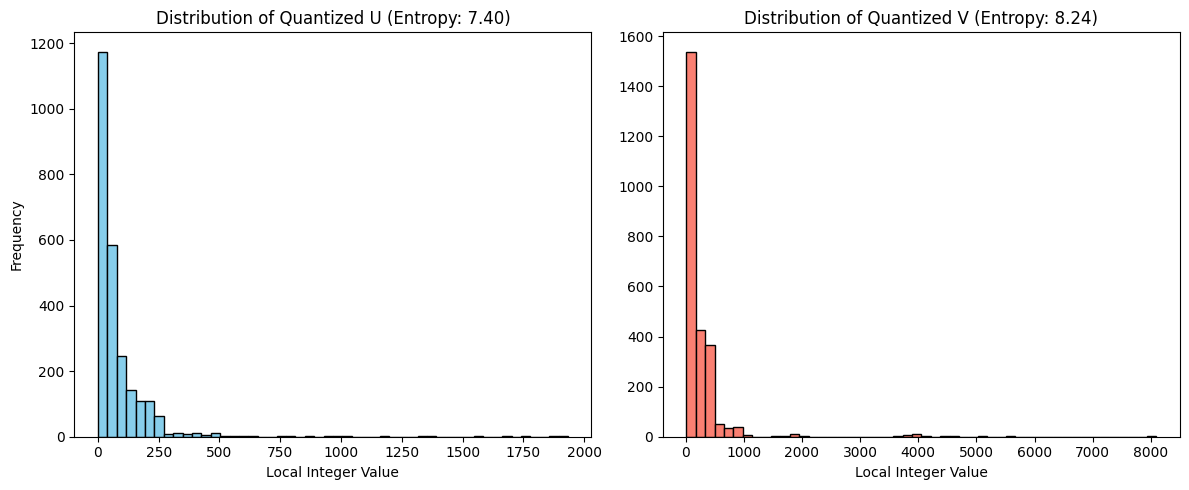

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- 1. Helpers ---

def generate_spherical_data(n=2000):
    """Generates clustered data (non-uniform distribution)."""
    # Clustered data compresses better than random data!
    c1 = np.random.normal(0.25, 0.05, (n//2, 2))
    c2 = np.random.normal(0.75, 0.05, (n//2, 2))
    data = np.vstack([c1, c2])
    return np.clip(data, 0.0, 0.99999)

def calculate_entropy(data_stream):
    """Computes Shannon Entropy (bits per symbol)."""
    if len(data_stream) == 0: return 0
    counts = Counter(data_stream)
    total = len(data_stream)
    entropy = 0.0
    for count in counts.values():
        p = count / total
        entropy -= p * np.log2(p)
    return entropy

# --- 2. Tree & Quantization Logic ---

class Node:
    def __init__(self, bounds, points, depth, axis):
        self.bounds = bounds
        self.points = points
        self.depth = depth
        self.axis = axis
        self.left = None
        self.right = None

def build_tree_recursive(points, bounds, depth, max_depth, axis, global_bits):
    node = Node(bounds, points, depth, axis)

    # A. Stop Condition (Leaf)
    # If few points or max depth reached
    if depth >= max_depth or len(points) <= 8:
        return node

    # B. Split
    min_u, min_v, max_u, max_v = bounds

    if axis == 0: # Split U
        mid = (min_u + max_u) / 2
        left_mask = points[:, 0] < mid
        bounds_L = (min_u, min_v, mid, max_v)
        bounds_R = (mid, min_v, max_u, max_v)
    else: # Split V
        mid = (min_v + max_v) / 2
        left_mask = points[:, 1] < mid
        bounds_L = (min_u, min_v, max_u, mid)
        bounds_R = (min_u, min_v, max_u, max_v)

    # Recurse
    next_axis = 1 - axis
    node.left = build_tree_recursive(points[left_mask], bounds_L, depth+1, max_depth, next_axis, global_bits)
    node.right = build_tree_recursive(points[~left_mask], bounds_R, depth+1, max_depth, next_axis, global_bits)

    return node

def collect_leaf_data(node, u_stream, v_stream, global_bits):
    """
    Traverses tree, quantizes leaf points, and appends to streams.
    """
    if node.left is None: # Leaf Node
        if len(node.points) == 0: return

        # 1. Determine Local Precision
        # Every split halves the range, saving 1 bit of requirement.
        # U splits = ceil(depth/2), V splits = floor(depth/2)
        u_splits = (node.depth + 1) // 2
        v_splits = (node.depth) // 2

        local_bits_u = max(1, global_bits - u_splits)
        local_bits_v = max(1, global_bits - v_splits)

        # 2. Normalize Points to Local Node Space [0, 1]
        min_u, min_v, max_u, max_v = node.bounds

        # Local coordinate = (Global - Min) / (Max - Min)
        # Handle div/0 for degenerate bounds
        width_u = max_u - min_u if max_u > min_u else 1.0
        width_v = max_v - min_v if max_v > min_v else 1.0

        local_u = (node.points[:, 0] - min_u) / width_u
        local_v = (node.points[:, 1] - min_v) / width_v

        # 3. Quantize to Integer
        # Max integer value = 2^bits - 1
        max_val_u = (1 << local_bits_u) - 1
        max_val_v = (1 << local_bits_v) - 1

        q_u = np.round(local_u * max_val_u).astype(int)
        q_v = np.round(local_v * max_val_v).astype(int)

        u_stream.extend(q_u)
        v_stream.extend(q_v)
        return

    # Internal Node
    collect_leaf_data(node.left, u_stream, v_stream, global_bits)
    collect_leaf_data(node.right, u_stream, v_stream, global_bits)

# --- 3. Execution ---

# Setup
global_precision = 16 # We want 16-bit global accuracy (65536 grid)
max_tree_depth = 24   # How deep we split
# points = generate_spherical_data(5000)
points = spherical_vertices_angles.copy()

# Build
root = build_tree_recursive(points, (0,0,1,1), 0, max_tree_depth, 0, global_precision)

# Collect Quantized Data
stream_u = []
stream_v = []
collect_leaf_data(root, stream_u, stream_v, global_precision)

# --- 4. Analysis ---

# A. Naive Size (Global 16-bit integers)
# naive_bits = len(points) * 2 * global_precision
naive_bits = len(points) * 2 * global_precision * 2

# B. Tree-Based Size (Simply storing reduced-bit integers)
# Note: This ignores the tree structure overhead (which is small, ~1 bit per point)
# We just want to compare the coordinate payload size.
# In a real file, you write: [Tree Header] + [Stream U] + [Stream V]
actual_bits_u = sum([max(1, global_precision - (max_tree_depth+1)//2) for _ in stream_u])
actual_bits_v = sum([max(1, global_precision - (max_tree_depth)//2) for _ in stream_v])
tree_bits = actual_bits_u + actual_bits_v # Approximation

# C. Arithmetic Coding Size (Entropy Limit)
# Calculate entropy of the quantized streams
ent_u = calculate_entropy(stream_u)
ent_v = calculate_entropy(stream_v)

arithmetic_bits = len(points) * (ent_u + ent_v)

# D. Print Results
print(f"--- Quantization & Entropy Analysis ---")
print(f"Global Precision: {global_precision} bits (Grid: {2**global_precision}x{2**global_precision})")
print(f"Points: {len(points)}")
print(f"\n1. Raw Storage (16-bit U + 16-bit V):")
print(f"   Size: {naive_bits / 8000:.2f} KB")

print(f"\n2. Tree-Based Quantization (Depth {max_tree_depth}):")
print(f"   (Reducing bits based on leaf size)")
print(f"   Size: {tree_bits / 8000:.2f} KB")
print(f"   Ratio: {naive_bits / tree_bits:.2f}x")

print(f"\n3. Arithmetic Coding Limit (Entropy):")
print(f"   (Compressing the quantized stream)")
print(f"   Entropy U: {ent_u:.2f} bits/symbol")
print(f"   Entropy V: {ent_v:.2f} bits/symbol")
print(f"   Size: {arithmetic_bits / 8000:.2f} KB")
print(f"   Total Ratio: {naive_bits / arithmetic_bits:.2f}x")

# --- 5. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot U Distribution
axes[0].hist(stream_u, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title(f"Distribution of Quantized U (Entropy: {ent_u:.2f})")
axes[0].set_xlabel("Local Integer Value")
axes[0].set_ylabel("Frequency")

# Plot V Distribution
axes[1].hist(stream_v, bins=50, color='salmon', edgecolor='black')
axes[1].set_title(f"Distribution of Quantized V (Entropy: {ent_v:.2f})")
axes[1].set_xlabel("Local Integer Value")

plt.tight_layout()
plt.show()

--- Compression Results (Global Model) ---
Original Raw Size:   10012 bytes
Tree Header Size:    386 bytes (Overhead)

[Method A] Tree + Fixed Bits (No Arithmetic Coding)
  Payload: 5060 bytes
  Total:   5446 bytes
  Ratio:   1.84x

[Method B] Tree + Arithmetic Coding (Global Entropy)
  Payload: 4725 bytes
  Total:   5112 bytes
  Ratio:   1.96x

SUCCESS: Arithmetic Coding saved 334 bytes over Fixed Tree.


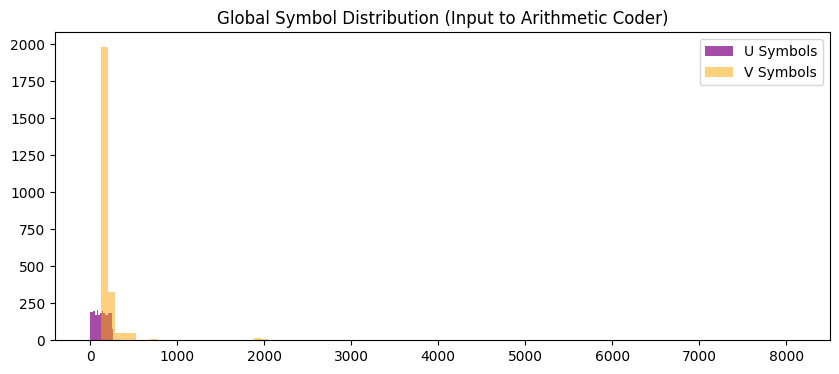

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- 1. Data Generation ---
def generate_spherical_data(n=5000):
    c1 = np.random.normal(0.2, 0.05, (n//4, 2))
    c2 = np.random.normal(0.8, 0.05, (n//4, 2))
    c3 = np.random.normal(0.5, 0.20, (n//4, 2))
    c4 = np.random.normal(0.5, 0.5, (n//4, 2)) # Noise
    data = np.vstack([c1, c2, c3, c4])
    return np.clip(data, 0.0, 0.99999)

# --- 2. Tree & Stats ---

class CompressionStats:
    def __init__(self):
        self.header_bits = 0
        self.total_bits_fixed = 0  # Naive sum of local bit-widths
        self.stream_u = []         # Collects ALL u values
        self.stream_v = []         # Collects ALL v values
        self.leaf_count = 0

def calculate_bits_for_count(n):
    if n == 0: return 0
    return np.log2(n + 1)

def process_node(points, bounds, depth, max_depth, axis, global_bits, stats):
    n_points = len(points)

    # --- A. Leaf Node ---
    if depth >= max_depth or n_points <= 4:
        stats.leaf_count += 1
        if n_points == 0: return

        # 1. Determine Local Precision (Bits needed)
        u_splits = (depth + 1) // 2
        v_splits = (depth) // 2
        local_bits_u = max(1, global_bits - u_splits)
        local_bits_v = max(1, global_bits - v_splits)

        # 2. Add to "Fixed" size counter (The naive approach)
        stats.total_bits_fixed += n_points * (local_bits_u + local_bits_v)

        # 3. Quantize and collect for "Entropy" (The arithmetic approach)
        min_u, min_v, max_u, max_v = bounds
        width_u = max_u - min_u
        width_v = max_v - min_v

        # Normalize to 0..1 within this leaf
        norm_u = (points[:, 0] - min_u) / width_u
        norm_v = (points[:, 1] - min_v) / width_v

        # Scale to integer range
        max_val_u = (1 << local_bits_u) - 1
        max_val_v = (1 << local_bits_v) - 1

        q_u = np.round(norm_u * max_val_u).astype(int)
        q_v = np.round(norm_v * max_val_v).astype(int)

        # Append to GLOBAL stream
        stats.stream_u.extend(q_u)
        stats.stream_v.extend(q_v)
        return

    # --- B. Internal Node ---

    # 1. Header Cost (Tree Structure)
    stats.header_bits += calculate_bits_for_count(n_points)

    # 2. Split
    min_u, min_v, max_u, max_v = bounds
    if axis == 0: # U Split
        mid = (min_u + max_u) / 2
        left_mask = points[:, 0] < mid
        bounds_L = (min_u, min_v, mid, max_v)
        bounds_R = (mid, min_v, max_u, max_v)
    else: # V Split
        mid = (min_v + max_v) / 2
        left_mask = points[:, 1] < mid
        bounds_L = (min_u, min_v, max_u, mid)
        bounds_R = (min_u, min_v, max_u, max_v)

    process_node(points[left_mask], bounds_L, depth+1, max_depth, 1-axis, global_bits, stats)
    process_node(points[~left_mask], bounds_R, depth+1, max_depth, 1-axis, global_bits, stats)

# --- 3. Execution ---

global_bits = 16
max_depth = 16
# points = generate_spherical_data(5000)
points = spherical_vertices_angles.copy()

stats = CompressionStats()
process_node(points, (0,0,1,1), 0, max_depth, 0, global_bits, stats)

# --- 4. Global Entropy Calculation ---

def calculate_stream_size(stream):
    """Calculates size of stream using Shannon Entropy."""
    if len(stream) == 0: return 0
    counts = Counter(stream)
    total = len(stream)
    entropy = 0.0
    for count in counts.values():
        p = count / total
        entropy -= p * np.log2(p)

    # Total bits = Entropy * Number of symbols
    return entropy * total

entropy_bits_u = calculate_stream_size(stats.stream_u)
entropy_bits_v = calculate_stream_size(stats.stream_v)
total_entropy_payload = entropy_bits_u + entropy_bits_v

# --- 5. Final Report ---

raw_size = len(points) * 2 * global_bits
tree_fixed_size = stats.header_bits + stats.total_bits_fixed
tree_entropy_size = stats.header_bits + total_entropy_payload

print(f"--- Compression Results (Global Model) ---")
print(f"Original Raw Size:   {raw_size/8:.0f} bytes")
print(f"Tree Header Size:    {stats.header_bits/8:.0f} bytes (Overhead)")

print(f"\n[Method A] Tree + Fixed Bits (No Arithmetic Coding)")
print(f"  Payload: {stats.total_bits_fixed/8:.0f} bytes")
print(f"  Total:   {tree_fixed_size/8:.0f} bytes")
print(f"  Ratio:   {raw_size / tree_fixed_size:.2f}x")

print(f"\n[Method B] Tree + Arithmetic Coding (Global Entropy)")
print(f"  Payload: {total_entropy_payload/8:.0f} bytes")
print(f"  Total:   {tree_entropy_size/8:.0f} bytes")
print(f"  Ratio:   {raw_size / tree_entropy_size:.2f}x")

# Validation check
if tree_entropy_size > tree_fixed_size:
    print("\nWARNING: Entropy size is larger. This usually means the data is uniform random (incompressible) or the header overhead is too high for small data.")
else:
    print(f"\nSUCCESS: Arithmetic Coding saved {(tree_fixed_size - tree_entropy_size)/8:.0f} bytes over Fixed Tree.")

# Visualize the Global Histogram
plt.figure(figsize=(10, 4))
plt.hist(stats.stream_u, bins=100, color='purple', alpha=0.7, label='U Symbols')
plt.hist(stats.stream_v, bins=100, color='orange', alpha=0.5, label='V Symbols')
plt.title("Global Symbol Distribution (Input to Arithmetic Coder)")
plt.legend()
plt.show()